In [1]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn as nn
from torchvision.utils import save_image
from tqdm.notebook import tqdm
import torch.nn.functional as F
from IPython.display import Image

### *1- Helper Functions*

In [2]:
%matplotlib inline

#Helper functions to denormalize the image tensors and display some sample images from a training batch.
def denorm(img_tensors):
    return img_tensors * stats[1][0] + stats[0][0]

def show_images(images, nmax=64):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(make_grid(denorm(images.detach()[:nmax]), nrow=8).permute(1, 2, 0))

def show_batch(dl, nmax=64):
    for images, _ in dl:
        show_images(images, nmax)
        break

In [3]:
# Helper function to export the generated images

def save_samples(index, latent_tensors, show=True):
    fake_images = generator(latent_tensors)
    fake_fname = 'generated-images-{0:0=4d}.png'.format(index)
    save_image(denorm(fake_images), os.path.join(sample_dir, fake_fname), nrow=8)
    print('Saving', fake_fname)
    if show:
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(fake_images.cpu().detach(), nrow=8).permute(1, 2, 0))

In [4]:
# Heler fuction to to move our model & data to the GPU
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
    
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl: 
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [5]:
device = get_default_device()
device

device(type='cuda')

### *2- Prepare Dataset*


In [6]:
!pip install opendatasets --upgrade --quiet

In [7]:
import opendatasets as od

dataset_url = 'https://www.kaggle.com/datasets/mariaherrerot/idrid-dataset'
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: chemousseberd
Your Kaggle Key: ··········


100%|██████████| 166M/166M [00:02<00:00, 61.4MB/s]


In [8]:
DATA_DIR = '/content/idrid-dataset/Imagenes'
print(os.listdir(DATA_DIR))

['Imagenes']


In [9]:
print(os.listdir(DATA_DIR+'/Imagenes')[:10])

['IDRiD_073test.jpg', 'IDRiD_039.jpg', 'IDRiD_290.jpg', 'IDRiD_131.jpg', 'IDRiD_085.jpg', 'IDRiD_036test.jpg', 'IDRiD_075.jpg', 'IDRiD_090test.jpg', 'IDRiD_231.jpg', 'IDRiD_089.jpg']


In [12]:
image_size = 64
batch_size = 1 #change it to 50
stats = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)

train_ds = ImageFolder(DATA_DIR, transform=T.Compose([
    T.Resize(image_size),
    T.CenterCrop(image_size),
    T.ToTensor(),
    T.Normalize(*stats)]))

#We will also create a data loader to load the data in batches.
train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=5, pin_memory=True)

In [ ]:
# Display some data
show_batch(train_dl)

In [14]:
#move our training data loader using DeviceDataLoader for automatically transferring batches of data to the GPU (if available).
train_dl = DeviceDataLoader(train_dl, device)

## *3- Prepare Discriminator Network*



In [15]:
discriminator = nn.Sequential(
    # in: 3 x 64 x 64

    nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 64 x 32 x 32

    nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 128 x 16 x 16

    nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 256 x 8 x 8

    nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 512 x 4 x 4

    nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False),
    # out: 1 x 1 x 1

    nn.Flatten(),
    nn.Sigmoid())

In [16]:
discriminator = to_device(discriminator, device)

## *4- Prepare Generator Network*


In [17]:
latent_size = 128

In [18]:
generator = nn.Sequential(
    # in: latent_size x 1 x 1

    nn.ConvTranspose2d(latent_size, 512, kernel_size=4, stride=1, padding=0, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    # out: 512 x 4 x 4

    nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(True),
    # out: 256 x 8 x 8

    nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),
    # out: 128 x 16 x 16

    nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),
    # out: 64 x 32 x 32

    nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1, bias=False),
    nn.Tanh()
    # out: 3 x 64 x 64
)

In [20]:
#summary(discriminator, input_size=(3, 64, 64))

In [21]:
#!pip install torchsummary

#from torchsummary import summary
#summary(generator, input_size=(128, 64, 64))

In [22]:
#!pip install hiddenlayer

In [23]:
#the output from the generator is basically random noise, since we haven't trained it yet.
"""xb = torch.randn(batch_size, latent_size, 1, 1) # random latent tensors
fake_images = generator(xb)
print(fake_images.shape)
show_images(fake_images)"""

'xb = torch.randn(batch_size, latent_size, 1, 1) # random latent tensors\nfake_images = generator(xb)\nprint(fake_images.shape)\nshow_images(fake_images)'

In [24]:
generator = to_device(generator, device)

## *5- Discriminator Training*


In [25]:
def train_discriminator(real_images, opt_d):
    # Clear discriminator gradients
    opt_d.zero_grad()

    # Pass real images through discriminator
    real_preds = discriminator(real_images)
    real_targets = torch.ones(real_images.size(0), 1, device=device)
    real_loss = F.binary_cross_entropy(real_preds, real_targets)
    real_score = torch.mean(real_preds).item()
    
    # Generate fake images
    latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
    fake_images = generator(latent)

    # Pass fake images through discriminator
    fake_targets = torch.zeros(fake_images.size(0), 1, device=device)
    fake_preds = discriminator(fake_images)
    fake_loss = F.binary_cross_entropy(fake_preds, fake_targets)
    fake_score = torch.mean(fake_preds).item()

    # Update discriminator weights
    loss = real_loss + fake_loss
    loss.backward()
    opt_d.step()
    return loss.item(), real_score, fake_score

## *6- Generator Training*



In [26]:
def train_generator(opt_g):
    # Clear generator gradients
    opt_g.zero_grad()
    
    # Generate fake images
    latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
    fake_images = generator(latent)
    
    # Try to fool the discriminator
    preds = discriminator(fake_images)
    targets = torch.ones(batch_size, 1, device=device)
    loss = F.binary_cross_entropy(preds, targets)
    
    # Update generator weights
    loss.backward()
    opt_g.step()
    
    return loss.item()

In [27]:
# Let's create a directory 
# where we can save intermediate outputs from the generator to visually inspect the progress of the model
sample_dir = 'generated'
os.makedirs(sample_dir, exist_ok=True)

In [28]:
#We'll use a fixed set of input vectors to the generator to see how the individual generated images evolve over time as we train the model. 
#Let's save one set of images before we start training our model.

fixed_latent = torch.randn(64, latent_size, 1, 1, device=device)

In [ ]:
save_samples(0, fixed_latent)

## *7- Full Training Loop*

In [30]:
def fit(epochs, lr, start_idx=1):
    torch.cuda.empty_cache()
    
    # Losses & scores
    losses_g = []
    losses_d = []
    real_scores = []
    fake_scores = []
    
    # Create optimizers
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    
    for epoch in range(epochs):
        for real_images, _ in tqdm(train_dl):
            # Train discriminator
            loss_d, real_score, fake_score = train_discriminator(real_images, opt_d)
            # Train generator
            loss_g = train_generator(opt_g)
            
        # Record losses & scores
        losses_g.append(loss_g)
        losses_d.append(loss_d)
        real_scores.append(real_score)
        fake_scores.append(fake_score)
        
        # Log losses & scores (last batch)
        print("Epoch [{}/{}], loss_g: {:.4f}, loss_d: {:.4f}, real_score: {:.4f}, fake_score: {:.4f}".format(
            epoch+1, epochs, loss_g, loss_d, real_score, fake_score))
    
        # Save generated images
        save_samples(epoch+start_idx, fixed_latent, show=False)
    
    return losses_g, losses_d, real_scores, fake_scores

In [31]:
lr = 0.0002
epochs = 50

In [32]:
history = fit(epochs, lr)

  0%|          | 0/455 [00:00<?, ?it/s]

Epoch [1/50], loss_g: 12.4455, loss_d: 0.0059, real_score: 0.9941, fake_score: 0.0000
Saving generated-images-0001.png


  0%|          | 0/455 [00:00<?, ?it/s]

Epoch [2/50], loss_g: 8.6690, loss_d: 1.2061, real_score: 0.9994, fake_score: 0.7004
Saving generated-images-0002.png


  0%|          | 0/455 [00:00<?, ?it/s]

...

Epoch [48/50], loss_g: 1.5667, loss_d: 1.3215, real_score: 0.3143, fake_score: 0.1513
Saving generated-images-0048.png


  0%|          | 0/455 [00:00<?, ?it/s]

Epoch [49/50], loss_g: 5.6236, loss_d: 0.0215, real_score: 0.9994, fake_score: 0.0207
Saving generated-images-0049.png


  0%|          | 0/455 [00:00<?, ?it/s]

Epoch [50/50], loss_g: 3.4237, loss_d: 0.0628, real_score: 0.9600, fake_score: 0.0217
Saving generated-images-0050.png


In [33]:
losses_g, losses_d, real_scores, fake_scores = history

Now that we have trained the models, we can save checkpoints.

In [34]:
# Save the model checkpoints 
torch.save(generator.state_dict(), 'Generator2.pth')
torch.save(discriminator.state_dict(), 'Discriminator2.pth')

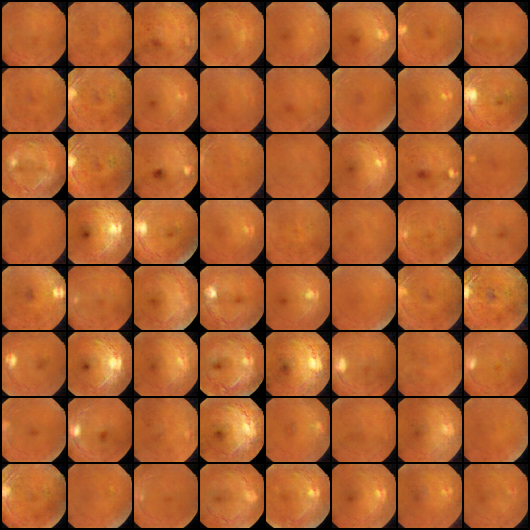

In [35]:
Image('./generated/generated-images-0050.png')

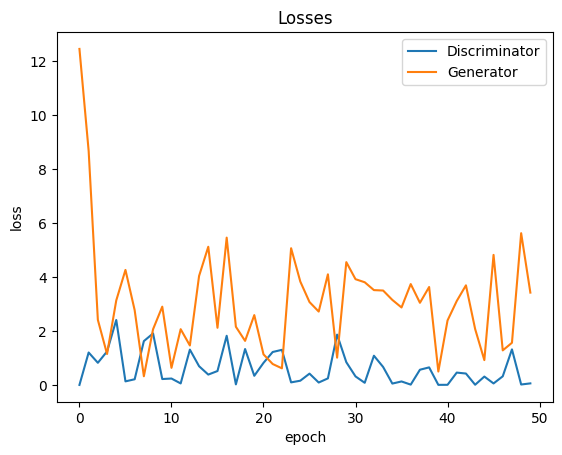

In [36]:
import cv2
import os

vid_fname = 'gans_training.avi'

files = [os.path.join(sample_dir, f) for f in os.listdir(sample_dir) if 'generated' in f]
files.sort()

out = cv2.VideoWriter(vid_fname,cv2.VideoWriter_fourcc(*'MP4V'), 1, (530,530))
[out.write(cv2.imread(fname)) for fname in files]
out.release()

plt.plot(losses_d, '-')
plt.plot(losses_g, '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.title('Losses');

